In [2]:
# Install required library

!pip install -q gradio imbalanced-learn

In [1]:
# ============================================================
# 1. IMPORT LIBRARIES AND UPLOAD DATASET
# ============================================================

import pandas as pd
import numpy as np

from google.colab import files

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename, low_memory=False)

print("Dataset loaded successfully")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.head())

Saving dft-road-casualty-statistics-collision-2025.csv to dft-road-casualty-statistics-collision-2025.csv
Dataset loaded successfully
Rows: 101525
Columns: 44


,collision_index,collision_year,collision_ref_no,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,collision_severity,number_of_vehicles,...,carriageway_hazards_historic,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,lsoa_of_accident_location,enhanced_severity_collision,collision_injury_based,collision_adjusted_severity_serious,collision_adjusted_severity_slight
0,202517M101925,2025,17M101925,447673.0,519279.0,-1.26420,54.56650,17,3,1,...,-1,0,1,1,2,E01012014,3,1,0.0,1.0
1,202517L205225,2025,17L205225,454611.0,518597.0,-1.15704,54.55967,17,3,2,...,-1,0,1,1,2,E01012173,3,1,0.0,1.0
2,2025070971700,2025,070971700,354476.0,382656.0,-2.68516,53.33884,7,3,2,...,-1,0,2,1,2,E01012444,3,1,0.0,1.0
3,2025070403274,2025,070403274,361793.0,393163.0,-2.57655,53.43386,7,3,2,...,-1,0,2,3,2,E01012468,3,1,0.0,1.0
4,2025071000604,2025,071000604,366083.0,389327.0,-2.51157,53.39967,7,3,7,...,-1,0,2,1,1,E01012551,3,1,0.0,1.0


In [3]:
# Check accident severity

print(df["collision_severity"].value_counts())

collision_severity
3    74881
2    25191
1     1453
Name: count, dtype: int64


In [4]:
# Check severity percentages

print(
    (df["collision_severity"].value_counts(normalize=True) * 100)
    .round(2)
)

collision_severity
3    73.76
2    24.81
1     1.43
Name: proportion, dtype: float64


In [5]:
# Separate the three severity classes

fatal = df[df["collision_severity"] == 1]
serious = df[df["collision_severity"] == 2]
slight = df[df["collision_severity"] == 3]

print("Original classes:")
print("Fatal   :", len(fatal))
print("Serious :", len(serious))
print("Slight  :", len(slight))

Original classes:
Fatal   : 1453
Serious : 25191
Slight  : 74881


In [6]:
# Balance the classes

from sklearn.utils import resample

smallest = min(
    len(fatal),
    len(serious),
    len(slight)
)

print("Number selected from each class:", smallest)

fatal_balanced = resample(
    fatal,
    replace=False,
    n_samples=smallest,
    random_state=42
)

serious_balanced = resample(
    serious,
    replace=False,
    n_samples=smallest,
    random_state=42
)

slight_balanced = resample(
    slight,
    replace=False,
    n_samples=smallest,
    random_state=42
)

balanced_df = pd.concat([
    fatal_balanced,
    serious_balanced,
    slight_balanced
])

balanced_df = balanced_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("Balanced dataset created!")
print(balanced_df["collision_severity"].value_counts())

Number selected from each class: 1453
Balanced dataset created!
collision_severity
2    1453
1    1453
3    1453
Name: count, dtype: int64


In [7]:
# Save balanced dataset

balanced_df.to_csv(
    "UK_STATS19_Balanced.csv",
    index=False
)

print("UK_STATS19_Balanced.csv saved successfully!")

UK_STATS19_Balanced.csv saved successfully!


In [8]:
# Select important features

features = [
    "speed_limit",
    "road_type",
    "light_conditions",
    "weather_conditions",
    "road_surface_conditions",
    "junction_detail",
    "urban_or_rural_area",
    "number_of_vehicles"
]

target = "collision_severity"

df_model = balanced_df[features + [target]].copy()

print("Selected features:")
print(features)

Selected features:
['speed_limit', 'road_type', 'light_conditions', 'weather_conditions', 'road_surface_conditions', 'junction_detail', 'urban_or_rural_area', 'number_of_vehicles']


In [9]:
# Remove rows where target is missing

df_model = df_model.dropna(
    subset=[target]
)

print("Rows after cleaning:", len(df_model))

Rows after cleaning: 4359


In [10]:
# Separate input features and target

X = df_model[features]
y = df_model[target]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (4359, 8)
y shape: (4359,)


In [11]:
# Check final class distribution

print(y.value_counts())

collision_severity
2    1453
1    1453
3    1453
Name: count, dtype: int64


In [12]:
# Split dataset into training and testing data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows :", len(X_test))

Training rows: 3487
Testing rows : 872


In [13]:
# Define feature types

numeric_features = [
    "number_of_vehicles"
]

categorical_features = [
    "speed_limit",
    "road_type",
    "light_conditions",
    "weather_conditions",
    "road_surface_conditions",
    "junction_detail",
    "urban_or_rural_area"
]

In [14]:
# Import preprocessing libraries

from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [15]:
# Numerical preprocessing

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

In [16]:
# Categorical preprocessing

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

In [17]:
# Combine preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [20]:
# Create ML pipeline

pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            model
        )
    ]
)

In [18]:
# Create Random Forest model

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

print("Random Forest created!")

Random Forest created!


In [21]:
# Train model

print("Training model...")

pipeline.fit(
    X_train,
    y_train
)

print("Model training completed!")

Training model...
Model training completed!


In [22]:
# Predict test data

y_pred = pipeline.predict(X_test)

print("Predictions completed!")

Predictions completed!


In [23]:
# Calculate accuracy

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Accuracy:",
    round(accuracy * 100, 2),
    "%"
)

Accuracy: 44.38 %


In [24]:
# Classification report

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        labels=[1, 2, 3],
        target_names=[
            "Fatal",
            "Serious",
            "Slight"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

       Fatal       0.50      0.54      0.52       290
     Serious       0.36      0.27      0.31       291
      Slight       0.45      0.52      0.48       291

    accuracy                           0.44       872
   macro avg       0.44      0.44      0.44       872
weighted avg       0.44      0.44      0.44       872



In [25]:
# Confusion matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=[1, 2, 3]
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[157  61  72]
 [ 98  79 114]
 [ 61  79 151]]


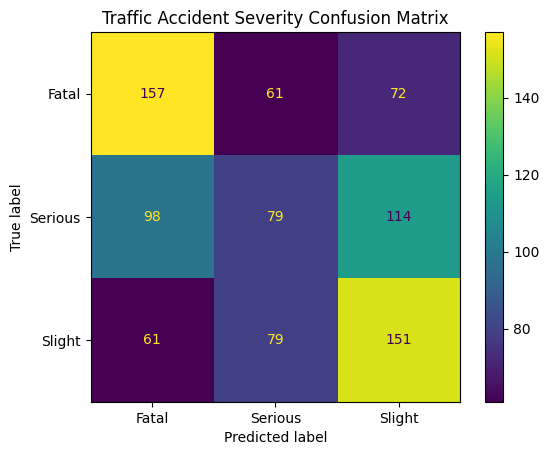

In [26]:
# Plot confusion matrix

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Fatal",
        "Serious",
        "Slight"
    ]
)

disp.plot()

plt.title("Traffic Accident Severity Confusion Matrix")
plt.show()

In [27]:
# Count predictions for each class

print(
    "Fatal predictions:",
    sum(y_pred == 1)
)

print(
    "Serious predictions:",
    sum(y_pred == 2)
)

print(
    "Slight predictions:",
    sum(y_pred == 3)
)

Fatal predictions: 316
Serious predictions: 219
Slight predictions: 337


In [28]:
# Get test examples predicted as each severity

fatal_examples = X_test[y_pred == 1]
serious_examples = X_test[y_pred == 2]
slight_examples = X_test[y_pred == 3]

print("Fatal examples:", len(fatal_examples))
print("Serious examples:", len(serious_examples))
print("Slight examples:", len(slight_examples))

Fatal examples: 316
Serious examples: 219
Slight examples: 337


In [29]:
# Display examples

print("========== FATAL EXAMPLE ==========")

if len(fatal_examples) > 0:
    print(fatal_examples.iloc[0])

print("\n========== SERIOUS EXAMPLE ==========")

if len(serious_examples) > 0:
    print(serious_examples.iloc[0])

print("\n========== SLIGHT EXAMPLE ==========")

if len(slight_examples) > 0:
    print(slight_examples.iloc[0])

========== FATAL EXAMPLE ==========
speed_limit                30
road_type                   6
light_conditions            1
weather_conditions          1
road_surface_conditions     1
junction_detail             0
urban_or_rural_area         1
number_of_vehicles          1
Name: 1864, dtype: int64

========== SERIOUS EXAMPLE ==========
speed_limit                20
road_type                   6
light_conditions            1
weather_conditions          1
road_surface_conditions     1
junction_detail            13
urban_or_rural_area         1
number_of_vehicles          2
Name: 86, dtype: int64

========== SLIGHT EXAMPLE ==========
speed_limit                30
road_type                   9
light_conditions            7
weather_conditions          2
road_surface_conditions     2
junction_detail            19
urban_or_rural_area         1
number_of_vehicles          2
Name: 599, dtype: int64


In [30]:
# Severity names

severity_names = {
    1: "Fatal",
    2: "Serious",
    3: "Slight"
}

In [31]:
# Test Fatal example

if len(fatal_examples) > 0:

    example = fatal_examples.iloc[[0]]

    prediction = pipeline.predict(example)[0]

    print(
        "Fatal example prediction:",
        severity_names[int(prediction)]
    )

Fatal example prediction: Fatal


In [32]:
# Test Serious example

if len(serious_examples) > 0:

    example = serious_examples.iloc[[0]]

    prediction = pipeline.predict(example)[0]

    print(
        "Serious example prediction:",
        severity_names[int(prediction)]
    )

Serious example prediction: Serious


In [33]:
# Test Slight example

if len(slight_examples) > 0:

    example = slight_examples.iloc[[0]]

    prediction = pipeline.predict(example)[0]

    print(
        "Slight example prediction:",
        severity_names[int(prediction)]
    )

Slight example prediction: Slight


In [34]:
# Install Gradio

!pip install -q gradio

In [35]:
# Get possible values for frontend

speed_values = sorted(
    df_model["speed_limit"]
    .dropna()
    .unique()
    .tolist()
)

road_values = sorted(
    df_model["road_type"]
    .dropna()
    .unique()
    .tolist()
)

light_values = sorted(
    df_model["light_conditions"]
    .dropna()
    .unique()
    .tolist()
)

weather_values = sorted(
    df_model["weather_conditions"]
    .dropna()
    .unique()
    .tolist()
)

surface_values = sorted(
    df_model["road_surface_conditions"]
    .dropna()
    .unique()
    .tolist()
)

junction_values = sorted(
    df_model["junction_detail"]
    .dropna()
    .unique()
    .tolist()
)

urban_values = sorted(
    df_model["urban_or_rural_area"]
    .dropna()
    .unique()
    .tolist()
)

In [36]:
# Prediction function for frontend

def predict_severity(
    speed_limit,
    road_type,
    light_conditions,
    weather_conditions,
    road_surface_conditions,
    junction_detail,
    urban_or_rural_area,
    number_of_vehicles
):

    input_data = pd.DataFrame([{

        "speed_limit": speed_limit,

        "road_type": road_type,

        "light_conditions": light_conditions,

        "weather_conditions": weather_conditions,

        "road_surface_conditions": road_surface_conditions,

        "junction_detail": junction_detail,

        "urban_or_rural_area": urban_or_rural_area,

        "number_of_vehicles": number_of_vehicles

    }])

    # Convert categorical values to strings

    for col in categorical_features:
        input_data[col] = input_data[col].astype(str)

    # Convert vehicles to number

    input_data["number_of_vehicles"] = float(
        number_of_vehicles
    )

    # Prediction

    prediction = pipeline.predict(
        input_data
    )[0]

    # Probability

    probabilities = pipeline.predict_proba(
        input_data
    )[0]

    classes = pipeline.named_steps[
        "classifier"
    ].classes_

    probability_dict = dict(
        zip(classes, probabilities)
    )

    fatal_probability = (
        probability_dict.get(1, 0) * 100
    )

    serious_probability = (
        probability_dict.get(2, 0) * 100
    )

    slight_probability = (
        probability_dict.get(3, 0) * 100
    )

    confidence = max(probabilities) * 100

    severity_names = {
        1: "Fatal",
        2: "Serious",
        3: "Slight"
    }

    severity = severity_names[
        int(prediction)
    ]

    return f"""
TRAFFIC ACCIDENT SEVERITY PREDICTION

Predicted Severity: {severity}

Model Confidence: {confidence:.2f}%

Severity Code: {prediction}

Probability:

Fatal   : {fatal_probability:.2f}%
Serious : {serious_probability:.2f}%
Slight  : {slight_probability:.2f}%
"""

In [41]:
# Install Gradio

!pip install -q gradio

In [42]:
# Get values for frontend dropdowns

speed_values = sorted(
    df_model["speed_limit"].dropna().unique().tolist()
)

road_values = sorted(
    df_model["road_type"].dropna().unique().tolist()
)

light_values = sorted(
    df_model["light_conditions"].dropna().unique().tolist()
)

weather_values = sorted(
    df_model["weather_conditions"].dropna().unique().tolist()
)

surface_values = sorted(
    df_model["road_surface_conditions"].dropna().unique().tolist()
)

junction_values = sorted(
    df_model["junction_detail"].dropna().unique().tolist()
)

urban_values = sorted(
    df_model["urban_or_rural_area"].dropna().unique().tolist()
)

In [43]:
# Create prediction function

def predict_severity(
    speed_limit,
    road_type,
    light_conditions,
    weather_conditions,
    road_surface_conditions,
    junction_detail,
    urban_or_rural_area,
    number_of_vehicles
):

    input_data = pd.DataFrame([{
        "speed_limit": speed_limit,
        "road_type": road_type,
        "light_conditions": light_conditions,
        "weather_conditions": weather_conditions,
        "road_surface_conditions": road_surface_conditions,
        "junction_detail": junction_detail,
        "urban_or_rural_area": urban_or_rural_area,
        "number_of_vehicles": number_of_vehicles
    }])

    # Convert categorical inputs to string

    for col in categorical_features:
        input_data[col] = input_data[col].astype(str)

    # Convert number of vehicles to number

    input_data["number_of_vehicles"] = float(
        number_of_vehicles
    )

    # Make prediction

    prediction = pipeline.predict(
        input_data
    )[0]

    # Get probabilities

    probabilities = pipeline.predict_proba(
        input_data
    )[0]

    classes = pipeline.named_steps[
        "classifier"
    ].classes_

    probability_dict = dict(
        zip(classes, probabilities)
    )

    # Get probabilities for each class

    fatal_probability = (
        probability_dict.get(1, 0) * 100
    )

    serious_probability = (
        probability_dict.get(2, 0) * 100
    )

    slight_probability = (
        probability_dict.get(3, 0) * 100
    )

    confidence = max(probabilities) * 100

    # Convert code to name

    severity_names = {
        1: "Fatal",
        2: "Serious",
        3: "Slight"
    }

    severity = severity_names.get(
        int(prediction),
        "Unknown"
    )

    return f"""
🚦 TRAFFIC ACCIDENT SEVERITY PREDICTION

Predicted Severity: {severity}

Model Confidence: {confidence:.2f}%

Severity Probabilities:

🔴 Fatal   : {fatal_probability:.2f}%
🟠 Serious : {serious_probability:.2f}%
🟢 Slight  : {slight_probability:.2f}%
"""

In [44]:
# Create Gradio frontend

import gradio as gr

with gr.Blocks() as demo:

    gr.Markdown(
        """
        # 🚦 Traffic Accident Severity Prediction

        Enter the accident conditions below and click
        **Predict Severity**.

        The model will predict:

        🔴 Fatal
        🟠 Serious
        🟢 Slight
        """
    )

    with gr.Row():

        speed_input = gr.Dropdown(
            choices=speed_values,
            label="Speed Limit"
        )

        road_input = gr.Dropdown(
            choices=road_values,
            label="Road Type"
        )

    with gr.Row():

        light_input = gr.Dropdown(
            choices=light_values,
            label="Light Conditions"
        )

        weather_input = gr.Dropdown(
            choices=weather_values,
            label="Weather Conditions"
        )

    with gr.Row():

        surface_input = gr.Dropdown(
            choices=surface_values,
            label="Road Surface Conditions"
        )

        junction_input = gr.Dropdown(
            choices=junction_values,
            label="Junction Detail"
        )

    with gr.Row():

        urban_input = gr.Dropdown(
            choices=urban_values,
            label="Urban or Rural Area"
        )

        vehicle_input = gr.Number(
            value=2,
            minimum=1,
            label="Number of Vehicles"
        )

    predict_button = gr.Button(
        "🔮 Predict Severity",
        variant="primary"
    )

    result = gr.Textbox(
        label="Prediction Result",
        lines=10
    )

    predict_button.click(
        fn=predict_severity,
        inputs=[
            speed_input,
            road_input,
            light_input,
            weather_input,
            surface_input,
            junction_input,
            urban_input,
            vehicle_input
        ],
        outputs=result
    )


demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7bfa73ee70f7af5721.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
